# NB5. Information Cascades

## 1. Network Simulation

A. Simulate a Random Network with N = 50 and p = 5%. Make a visualization of the graph. Make sure your network is connected.

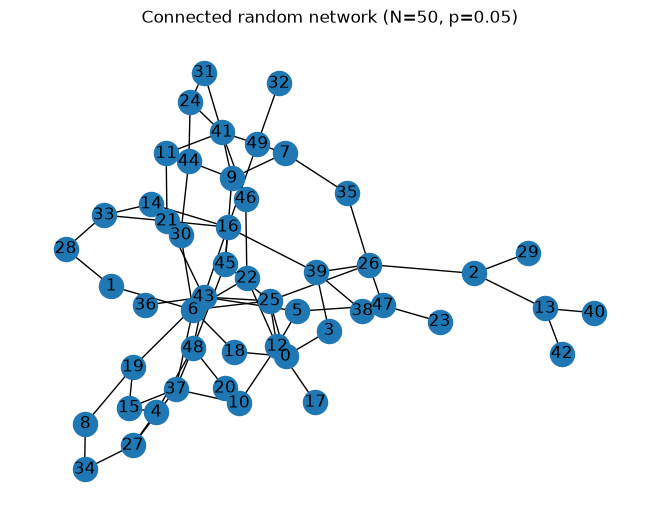

Nodes: 50
Edges: 74


In [1]:
import itertools
import random
import networkx as nx
import matplotlib.pyplot as plt

def gnp_random_graph(N, p):
    G = nx.Graph()
    G.add_nodes_from(range(N))

    for i, j in itertools.combinations(G.nodes, 2):
        r = random.random()
        if r < p:
            G.add_edge(i, j)

    return G

def gnm_random_graph(N, M):
    G = nx.Graph()
    G.add_nodes_from(range(N))

    possible_edges = itertools.combinations(G.nodes, 2)
    edges_to_add = random.sample(list(possible_edges), M)
    G.add_edges_from(edges_to_add)

    return G

def barabasi_albert_graph(N, m):
    G = nx.complete_graph(m + 1)
    for i in range(G.number_of_nodes(), N):
        new_neighbors = []
        possible_neighbors = list(G.nodes)
        for _ in range(m):
            degrees = [G.degree(n) for n in possible_neighbors]
            j = random.choices(possible_neighbors, degrees)[0]
            new_neighbors.append(j)
            possible_neighbors.remove(j)

        for j in new_neighbors:
            G.add_edge(i, j)

    return G

random.seed(42)
while True:
    G = gnp_random_graph(50, 0.05)
    if nx.is_connected(G):
        break

fig = plt.figure()
nx.draw(G, with_labels=True)
plt.title('Connected random network (N=50, p=0.05)')
plt.show()

print('Nodes:', G.number_of_nodes())
print('Edges:', G.number_of_edges())

## 2. Fractional Threshold Model
1. Implement an algorithm to simulate the information spread using the fractional threshold model. Consider a synchronous implementation.
2. Complete the following considering a copy of the network at the section 1:
    
    a) Initialize as 'Active' a random sample with 10% of the total network. The rest of the network will be initialized as 'Inactive'.
    
    b) How much nodes are vulnerable nodes?
    
    c) Simulate the information spread with $\theta = \frac{1}{2}$ until no further nodes can be activate. Plot the proportion of nodes in each state ('Active' and 'Inactive') at each step of the simulation.
    
    d) Create an animation (GIF Image) showing the state of the graph at each step.  
    

Initial active nodes: 5
Vulnerable nodes: 3
Stop condition met at step 3.


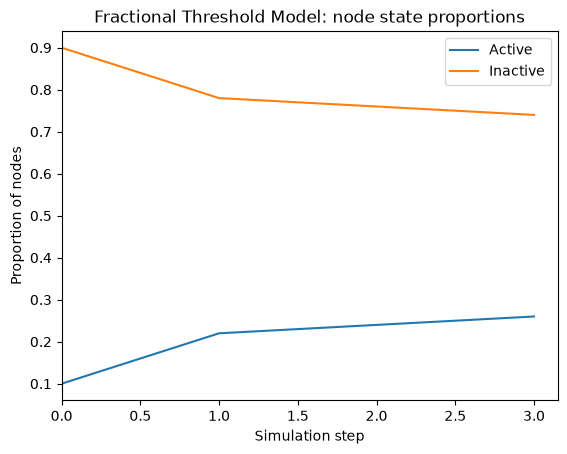

GIF saved as threshold_model.gif
Final active proportion: 0.26


In [2]:
import io
from PIL import Image
from simulation import Simulation

THETA = 1 / 2
G_threshold = G.copy()

def initial_state(G):
    state = {}
    for node in G.nodes:
        state[node] = 'Inactive'

    n_active = int(0.10 * G.number_of_nodes())
    active_nodes = random.sample(list(G.nodes), n_active)
    for node in active_nodes:
        state[node] = 'Active'
    return state

def count_vulnerable(G, current_state, theta):
    vulnerable = 0
    for node in G.nodes:
        if current_state[node] == 'Inactive' and G.degree(node) > 0:
            active_neighbors = sum(
                1 for neighbor in G.neighbors(node)
                if current_state[neighbor] == 'Active'
            )
            if active_neighbors / G.degree(node) >= theta:
                vulnerable += 1
    return vulnerable

def state_transition(G, current_state):
    next_state = {}
    for node in G.nodes:
        if current_state[node] == 'Inactive' and G.degree(node) > 0:
            active_neighbors = sum(
                1 for neighbor in G.neighbors(node)
                if current_state[neighbor] == 'Active'
            )
            if active_neighbors / G.degree(node) >= THETA:
                next_state[node] = 'Active'
    return next_state

def stop_condition(G, current_state):
    for node in G.nodes:
        if current_state[node] == 'Inactive' and G.degree(node) > 0:
            active_neighbors = sum(
                1 for neighbor in G.neighbors(node)
                if current_state[neighbor] == 'Active'
            )
            if active_neighbors / G.degree(node) >= THETA:
                return False
    return True

random.seed(42)
initial = initial_state(G_threshold)
print('Initial active nodes:', sum(1 for v in initial.values() if v == 'Active'))
print('Vulnerable nodes:', count_vulnerable(G_threshold, initial, THETA))

sim = Simulation(G_threshold, initial_state, state_transition, stop_condition,
                 name='Fractional Threshold Model')
sim.run(100)

sim.plot(labels=['Active', 'Inactive'])
plt.show()

def save_simulation_gif(simulation, filename):
    frames = []
    for step in range(simulation.steps + 1):
        simulation.draw(step, labels=['Active', 'Inactive'])
        buffer = io.BytesIO()
        plt.savefig(buffer, format='png', bbox_inches='tight')
        plt.close()
        buffer.seek(0)
        frames.append(Image.open(buffer).copy())

    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=500,
        loop=0,
    )

save_simulation_gif(sim, 'threshold_model.gif')
print('GIF saved as threshold_model.gif')
print('Final active proportion:',
      sum(1 for v in sim.state().values() if v == 'Active') / G_threshold.number_of_nodes())

## 3. Independent Cascade Model

1. Implement an algorithm to simulate the information spread using the a independent cascade model.
2. Complete the following considering a copy of the network at the section 1:
    
    a) Initialize as 'Active' a random sample with 10% of the total network. The rest of the network will be initialized as 'Inactive'.
        
    b) Simulate the information until no further nodes can be activate. Consider that the probability $P_{v,w}$, i. e. probability that node w gets activated due to v, is given by a constant P = 0.5 for any node in the network. Plot the proportion of nodes in each state ('Active' and 'Inactive') at each step of the simulation.
    
    c) Create an animation (GIF Image) showing the state of the graph at each step. 

Stop condition met at step 11.


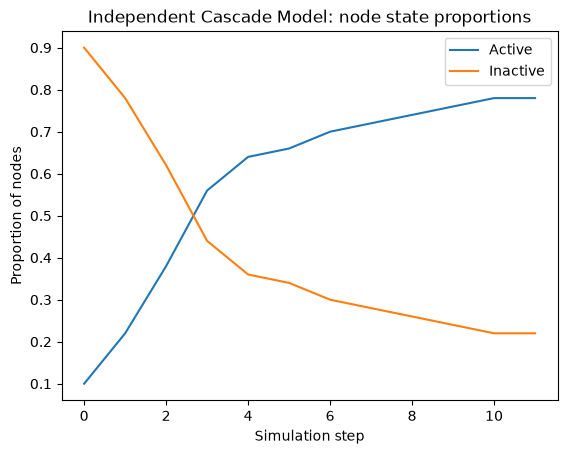

GIF saved as independent_cascade.gif
Final active nodes: 39


In [3]:
from simulation import Simulation

P = 0.5
G_ic = G.copy()

def initial_state_ic(G):
    state = {}
    for node in G.nodes:
        state[node] = 'Inactive'

    n_active = int(0.10 * G.number_of_nodes())
    active_nodes = random.sample(list(G.nodes), n_active)
    for node in active_nodes:
        state[node] = 'New'
    return state

def state_transition_ic(G, current_state):
    next_state = {}

    for node in G.nodes:
        if current_state[node] == 'New':
            for neighbor in G.neighbors(node):
                if current_state[neighbor] == 'Inactive':
                    if random.random() < P:
                        next_state[neighbor] = 'New'

    for node in G.nodes:
        if current_state[node] == 'New':
            next_state[node] = 'Active'

    return next_state

def stop_condition_ic(G, current_state):
    return not any(value == 'New' for value in current_state.values())

random.seed(42)
sim_ic = Simulation(G_ic, initial_state_ic, state_transition_ic, stop_condition_ic,
                    name='Independent Cascade Model')
sim_ic.run(100)

# Plot proportions treating newly activated nodes as Active.
active_props = []
inactive_props = []
for step in range(sim_ic.steps + 1):
    state = sim_ic.state(step)
    n = G_ic.number_of_nodes()
    active = sum(1 for value in state.values() if value in ('Active', 'New'))
    inactive = n - active
    active_props.append(active / n)
    inactive_props.append(inactive / n)

fig = plt.figure()
plt.plot(range(sim_ic.steps + 1), active_props, label='Active')
plt.plot(range(sim_ic.steps + 1), inactive_props, label='Inactive')
plt.xlabel('Simulation step')
plt.ylabel('Proportion of nodes')
plt.title('Independent Cascade Model: node state proportions')
plt.legend()
plt.show()

save_simulation_gif(sim_ic, 'independent_cascade.gif')
print('GIF saved as independent_cascade.gif')
print('Final active nodes:', int(active_props[-1] * G_ic.number_of_nodes()))

## 4. Maximazing the Information Spread

1. Implement the algorithm to find the set S with size k that maximize the information spread based on the Greedy Algorithm proposed by Kempe (2003). 
2. Find the set S with size k = 10 that maximize the influence for each Network taking into account that the probability $P_{v,w}$, i. e. probability that node w gets activated due to v, is given by a constant P = 0.5 for any node in the network.

In [4]:
def run_independent_cascade(G, seed_set, activation_prob, trials=30):
    spreads = []

    for _ in range(trials):
        state = {node: 'Inactive' for node in G.nodes}
        for node in seed_set:
            state[node] = 'New'

        while any(value == 'New' for value in state.values()):
            next_state = {}

            for node in G.nodes:
                if state[node] == 'New':
                    for neighbor in G.neighbors(node):
                        if state[neighbor] != 'Inactive':
                            continue

                        if callable(activation_prob):
                            p = activation_prob(G, node, neighbor)
                        else:
                            p = activation_prob

                        if random.random() < p:
                            next_state[neighbor] = 'New'

            for node in G.nodes:
                if state[node] == 'New':
                    next_state[node] = 'Active'

            state.update(next_state)

        spreads.append(sum(1 for value in state.values() if value == 'Active'))

    return sum(spreads) / len(spreads)

def greedy_influence_maximization(G, k, activation_prob, trials=30):
    seed_set = set()

    for step in range(k):
        best_node = None
        best_spread = -1

        for node in G.nodes:
            if node in seed_set:
                continue

            spread = run_independent_cascade(G, seed_set | {node}, activation_prob, trials)
            if spread > best_spread:
                best_spread = spread
                best_node = node

        seed_set.add(best_node)
        print(f'Step {step + 1}: added node {best_node}, expected spread = {best_spread:.2f}')

    return seed_set

G_greedy = G.copy()
random.seed(42)

print('Greedy influence maximization on the Section 1 network (k=10, P=0.5):')
seed_set = greedy_influence_maximization(G_greedy, k=10, activation_prob=0.5)
print('Selected seed set:', sorted(seed_set))
print('Expected final spread:', run_independent_cascade(G_greedy, seed_set, 0.5))

Greedy influence maximization on the Section 1 network (k=10, P=0.5):
Step 1: added node 6, expected spread = 27.00
Step 2: added node 42, expected spread = 30.53
Step 3: added node 44, expected spread = 32.33
Step 4: added node 27, expected spread = 33.47
Step 5: added node 4, expected spread = 35.20
Step 6: added node 35, expected spread = 35.80
Step 7: added node 38, expected spread = 36.10
Step 8: added node 32, expected spread = 37.77
Step 9: added node 17, expected spread = 38.70
Step 10: added node 23, expected spread = 39.53
Selected seed set: [4, 6, 17, 23, 27, 32, 35, 38, 42, 44]
Expected final spread: 37.03333333333333


## 5. Wrapping all together

1. Simulate an Erdos-Renyi and a Barabasi-Albert Network with 50 nodes and 150 nodes. Make a visualization of each network.
2. Find the set S with size k = 10 that maximize the influence for each Network taking into account the following hypotesis:
    * Hypotesis 1: The probability $P_{v,w}$, i. e. probability that node w gets activated due to w, is given by a constant P = 0.5 for any node in the network.
    * Hypotesis 2: Now, take into account that $P_{v,w}$ is given by the Node Similarity. Let $N(v_v)$ and $N(v_w)$ be the neighbors of vertices $v_v$ and $v_w$, respectively. The Jaccard Node Similarity between both nodes is given by:
$$\sigma_{Jaccard}(v_v, v_w) = \frac{|N(v_v) \cap N(v_w)|}{|N(v_v) \cup N(v_w)|}$$


In general, the definition of neighborhood $N(v_i)$ excludes the node itself $(v_i)$. This, however, leads to problems with similarity values because nodes that are connected and do not share a neighbor will be assigned zero similarity. This can be rectified by assuming that nodes are included in their own neighborhood.

> Note: You need to complete one simulation per hypotesis. 

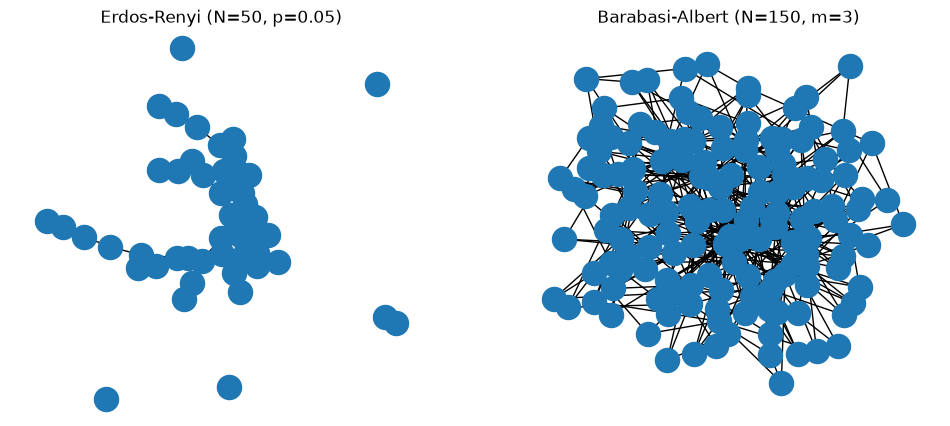


Erdos-Renyi
Hypothesis 1: constant P = 0.5
Step 1: added node 48, expected spread = 14.95
Step 2: added node 42, expected spread = 19.55
Step 3: added node 12, expected spread = 20.85
Step 4: added node 40, expected spread = 23.30
Step 5: added node 13, expected spread = 26.20
Step 6: added node 25, expected spread = 27.10
Step 7: added node 7, expected spread = 29.30
Step 8: added node 15, expected spread = 29.50
Step 9: added node 37, expected spread = 30.30
Step 10: added node 11, expected spread = 32.55
Seed set: [7, 11, 12, 13, 15, 25, 37, 40, 42, 48]
Expected spread: 31.73
Hypothesis 2: P(v,w) = Jaccard node similarity
Step 1: added node 29, expected spread = 6.00
Step 2: added node 42, expected spread = 9.55
Step 3: added node 48, expected spread = 11.90
Step 4: added node 17, expected spread = 13.70
Step 5: added node 6, expected spread = 15.90
Step 6: added node 12, expected spread = 18.15
Step 7: added node 40, expected spread = 20.70
Step 8: added node 26, expected spread =

In [5]:
random.seed(42)
G_er = gnp_random_graph(50, 0.05)
G_ba = barabasi_albert_graph(150, 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
nx.draw(G_er, ax=axes[0], with_labels=False)
axes[0].set_title('Erdos-Renyi (N=50, p=0.05)')

nx.draw(G_ba, ax=axes[1], with_labels=False)
axes[1].set_title('Barabasi-Albert (N=150, m=3)')
plt.show()

def neighborhood(G, node):
    return set(G.neighbors(node)) | {node}

def jaccard_activation_prob(G, v, w):
    Nv = neighborhood(G, v)
    Nw = neighborhood(G, w)
    return len(Nv & Nw) / len(Nv | Nw)

networks = {
    'Erdos-Renyi': G_er,
    'Barabasi-Albert': G_ba,
}

for network_name, graph in networks.items():
    print(f'\n{network_name}')

    print('Hypothesis 1: constant P = 0.5')
    random.seed(42)
    seeds_h1 = greedy_influence_maximization(graph, k=10, activation_prob=0.5, trials=20)
    spread_h1 = run_independent_cascade(graph, seeds_h1, 0.5, trials=30)
    print('Seed set:', sorted(seeds_h1))
    print('Expected spread:', round(spread_h1, 2))

    print('Hypothesis 2: P(v,w) = Jaccard node similarity')
    random.seed(42)
    seeds_h2 = greedy_influence_maximization(graph, k=10, activation_prob=jaccard_activation_prob, trials=20)
    spread_h2 = run_independent_cascade(graph, seeds_h2, jaccard_activation_prob, trials=30)
    print('Seed set:', sorted(seeds_h2))
    print('Expected spread:', round(spread_h2, 2))